# 💳 Profit-Optimized Credit Approval System
### LendingClub Dataset 2007–2018 | Full 9-Phase Build

**Mission:**  
> *Which loan applications should be approved to maximize expected profit while controlling default risk?*

This is not a classification exercise. This is a **capital allocation engine under uncertainty.**

---
| Phase | Name | Description |
|-------|------|-------------|
| 0 | Business Foundation | Economics, profit equation, break-even math |
| 1 | Clean Risk Dataset | Preprocessing, feature engineering |
| 2 | Risk Intelligence | EDA — where does the 20% default hide? |
| 3 | Baseline Rule System | Simple underwriting rules + benchmark |
| 4 | ML Risk Model | Logistic Regression + Random Forest, AUC |
| 5 | Decision Intelligence | PD → Expected Profit → Approval threshold |
| 6 | Portfolio Optimization | Capital constraints, rank by expected profit |
| 7 | Stress Testing | 3 macro scenarios — does profit survive? |
| 8 | System Design | End-to-end approval function |
| 9 | Executive Summary | README-ready final report |

---
# ⚙️ Global Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report
)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
SEED = 42
np.random.seed(SEED)

# ─── COLOUR PALETTE ───────────────────────────────────────────────────────────
C_GREEN  = '#27ae60'
C_RED    = '#e74c3c'
C_BLUE   = '#2980b9'
C_ORANGE = '#e67e22'
C_PURPLE = '#8e44ad'
C_DARK   = '#2c3e50'

print('✅  Libraries loaded.')

✅  Libraries loaded.


---
# 🔵 PHASE 0 — Business Foundation
**Anchor yourself before touching data.  
Define the economics, the profit equation, and the break-even math.**

In [2]:
# ─── BUSINESS PARAMETERS (tune these to change the system's risk appetite) ────

# Loan economics
LGD         = 0.80   # Loss Given Default: % of principal we lose (industry: 60-90%)
RECOVERY    = 0.20   # % of defaulted principal recovered (via collections)
OPEX_RATE   = 0.01   # Origination + servicing cost as % of principal
COST_OF_CAP = 0.04   # Opportunity cost of capital (risk-free rate), annualised

# Capital constraint (Phase 6)
MAX_PORTFOLIO_LOANS   = 2000    # Max loans we can fund
MAX_PORTFOLIO_CAPITAL = 50_000_000  # $50M capital ceiling

# ─── PROFIT EQUATION ──────────────────────────────────────────────────────────
# E[Profit] = (1-PD) * Interest_Income  -  PD * Loss_Amount  -  OpEx
#
# For a loan of amount L, annual rate r, over t years:
#   Interest Income = L * r * t
#   Loss Amount     = L * LGD
#   OpEx            = L * OPEX_RATE
#
# → E[Profit] = (1-PD)*L*r*t - PD*L*LGD - L*OPEX_RATE

# ─── BREAK-EVEN PD (analytical solution) ──────────────────────────────────────
# Set E[Profit] = 0 and solve for PD:
#
#   PD_breakeven = (r*t - OPEX_RATE) / (LGD + r*t)

def breakeven_pd(int_rate_pct, term_months, lgd=LGD, opex=OPEX_RATE):
    """Maximum PD at which a loan is still profitable."""
    r = int_rate_pct / 100
    t = term_months / 12
    return max(0.0, min(1.0, (r * t - opex) / (lgd + r * t)))

def expected_profit(pd, loan_amnt, int_rate_pct, term_months, lgd=LGD, opex=OPEX_RATE):
    """Expected dollar profit for a single loan."""
    r = int_rate_pct / 100
    t = term_months / 12
    return (1 - pd) * loan_amnt * r * t - pd * loan_amnt * lgd - loan_amnt * opex

# ─── PRINT THE ECONOMICS ──────────────────────────────────────────────────────
print('='*60)
print('LOAN ECONOMICS')
print('='*60)
print(f'  Loss Given Default (LGD)  : {LGD:.0%}')
print(f'  Recovery Rate             : {RECOVERY:.0%}')
print(f'  Operational Cost (OpEx)   : {OPEX_RATE:.0%} of principal')
print(f'  Cost of Capital           : {COST_OF_CAP:.0%} p.a.')
print()
print('BREAK-EVEN PD BY INTEREST RATE & TERM:')
print(f'{"Rate":>8} | {"36-mo":>8} | {"60-mo":>8}')
print('-'*32)
for rate in [7, 10, 13, 16, 20, 25]:
    be36 = breakeven_pd(rate, 36)
    be60 = breakeven_pd(rate, 60)
    print(f'{rate:>6}%  | {be36:>7.1%}  | {be60:>7.1%}')
print()
print('Interpretation: a 20% / 60-month loan can absorb up to')
print(f'{breakeven_pd(20, 60):.1%} default probability and still generate profit.')

LOAN ECONOMICS
  Loss Given Default (LGD)  : 80%
  Recovery Rate             : 20%
  Operational Cost (OpEx)   : 1% of principal
  Cost of Capital           : 4% p.a.

BREAK-EVEN PD BY INTEREST RATE & TERM:
    Rate |    36-mo |    60-mo
--------------------------------
     7%  |   19.8%  |   29.6%
    10%  |   26.4%  |   37.7%
    13%  |   31.9%  |   44.1%
    16%  |   36.7%  |   49.4%
    20%  |   42.1%  |   55.0%
    25%  |   47.7%  |   60.5%

Interpretation: a 20% / 60-month loan can absorb up to
55.0% default probability and still generate profit.


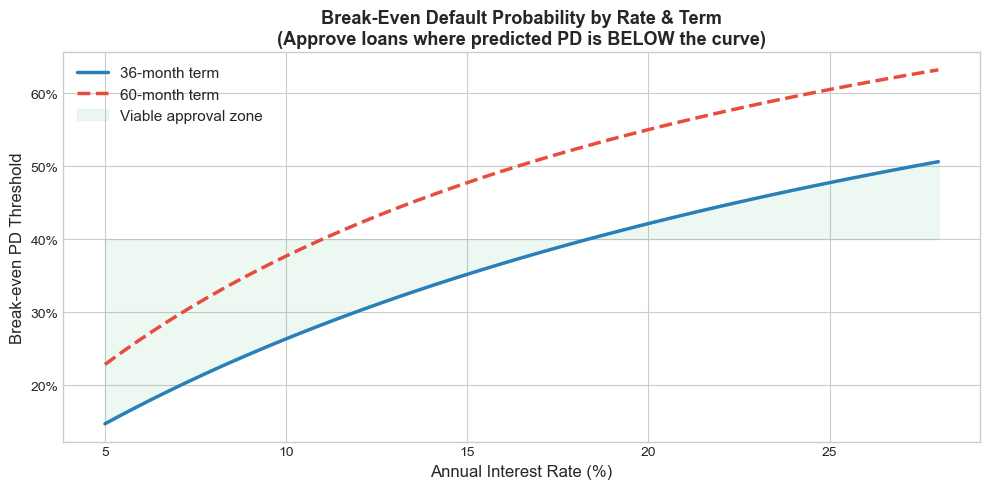

In [3]:
# Visualise break-even surface
rates = np.linspace(5, 28, 100)
fig, ax = plt.subplots(figsize=(10, 5))

for term, color, ls in [(36, C_BLUE, '-'), (60, C_RED, '--')]:
    be_vals = [breakeven_pd(r, term) for r in rates]
    ax.plot(rates, be_vals, color=color, linewidth=2.5,
            linestyle=ls, label=f'{term}-month term')

ax.fill_between(rates, [breakeven_pd(r, 36) for r in rates], 0.4,
                alpha=0.08, color=C_GREEN, label='Viable approval zone')
ax.set_xlabel('Annual Interest Rate (%)', fontsize=12)
ax.set_ylabel('Break-even PD Threshold', fontsize=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Break-Even Default Probability by Rate & Term\n'
             '(Approve loans where predicted PD is BELOW the curve)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('phase0_breakeven.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 🔵 PHASE 1 — Clean Risk Dataset
**Build a modeling-ready dataset using ONLY underwriting-time features.**

In [4]:
# ─── CONFIGURATION ────────────────────────────────────────────────────────────
DATA_PATH = r"C:\Users\komal\Desktop\e-e business analytics\accepted_2007_to_2018q4.csv\accepted_2007_to_2018Q4.csv"

# Underwriting-time features only (nothing you'd only know AFTER loan is issued)
KEEP_COLS = [
    'loan_status',       # target
    'loan_amnt',         # requested amount
    'term',              # 36 or 60 months
    'int_rate',          # assigned interest rate
    'installment',       # monthly payment
    'grade',             # LendingClub risk grade A-G
    'sub_grade',         # finer grade A1-G5
    'purpose',           # loan purpose
    'application_type',  # individual vs joint
    'annual_inc',        # borrower income
    'verification_status',
    'dti',               # debt-to-income ratio
    'emp_length',        # employment length
    'home_ownership',
    'addr_state',
    'fico_range_low',
    'fico_range_high',
    'earliest_cr_line',  # credit history start
    'open_acc',
    'total_acc',
    'revol_bal',
    'revol_util',
    'pub_rec',
    'delinq_2yrs',
    'inq_last_6mths',
    'mort_acc',
    'tot_cur_bal',
    'tot_hi_cred_lim',
]

print('Loading data...')
raw = pd.read_csv(DATA_PATH, usecols=KEEP_COLS, low_memory=False, nrows=300_000)
print(f'Raw shape: {raw.shape[0]:,} rows × {raw.shape[1]} cols')

Loading data...
Raw shape: 300,000 rows × 28 cols


In [5]:
# ─── STEP 1: Remove ambiguous loan statuses ───────────────────────────────────
AMBIGUOUS = ['Current', 'In Grace Period', 'Late (16-30 days)', 
             'Late (31-120 days)', 'Issued']
df = raw[~raw['loan_status'].isin(AMBIGUOUS)].copy()
print(f'After removing ambiguous statuses: {df.shape[0]:,} rows')
print(df['loan_status'].value_counts())

After removing ambiguous statuses: 265,777 rows
loan_status
Fully Paid     212275
Charged Off     53501
Default             1
Name: count, dtype: int64


In [6]:
# ─── STEP 2: Binary target ─────────────────────────────────────────────────────
df['default'] = df['loan_status'].isin(['Charged Off', 'Default']).astype(int)
df.drop('loan_status', axis=1, inplace=True)
print(f'Default rate: {df["default"].mean():.2%}')

Default rate: 20.13%


In [7]:
# ─── STEP 3: Feature engineering ──────────────────────────────────────────────

# term → integer months
df['term_months'] = df['term'].str.extract(r'(\d+)').astype(float)
df.drop('term', axis=1, inplace=True)

# FICO midpoint
df['fico'] = (df['fico_range_low'] + df['fico_range_high']) / 2
df.drop(['fico_range_low', 'fico_range_high'], axis=1, inplace=True)

# Credit age in years
REF_DATE = pd.Timestamp('2018-12-31')
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y', errors='coerce')
df['credit_age_yrs'] = (REF_DATE - df['earliest_cr_line']).dt.days / 365.25
df.drop('earliest_cr_line', axis=1, inplace=True)

# emp_length → numeric
EMP_MAP = {'< 1 year': 0.5, '1 year': 1, '2 years': 2, '3 years': 3,
           '4 years': 4, '5 years': 5, '6 years': 6, '7 years': 7,
           '8 years': 8, '9 years': 9, '10+ years': 11, 'n/a': -1}
df['emp_length_num'] = df['emp_length'].map(EMP_MAP).fillna(-1)
df.drop('emp_length', axis=1, inplace=True)

# Derived financial ratios
df['monthly_inc']        = df['annual_inc'] / 12
df['payment_to_income']  = df['installment'] / df['monthly_inc'].clip(lower=1)
df['loan_to_income']     = df['loan_amnt'] / df['annual_inc'].clip(lower=1)
df['debt_to_credit']     = df['tot_cur_bal'] / df['tot_hi_cred_lim'].clip(lower=1)
df['acc_breadth']        = df['open_acc'] / df['total_acc'].clip(lower=1)
df['high_util_flag']     = (df['revol_util'] > 80).astype(int)

# grade/sub_grade → ordinal integer
GRADE_MAP = {g: i for i, g in enumerate('ABCDEFG')}
df['grade_num']    = df['grade'].map(GRADE_MAP).fillna(6)
subgrades = [f'{g}{n}' for g in 'ABCDEFG' for n in range(1, 6)]
SUBGRADE_MAP = {sg: i for i, sg in enumerate(subgrades)}
df['subgrade_num'] = df['sub_grade'].map(SUBGRADE_MAP).fillna(34)
df.drop(['grade', 'sub_grade'], axis=1, inplace=True)

# State → frequency encoding
state_freq = df['addr_state'].value_counts(normalize=True)
df['state_freq'] = df['addr_state'].map(state_freq)
df.drop('addr_state', axis=1, inplace=True)

# Remaining categoricals → label encode
for col in ['purpose', 'application_type', 'verification_status', 'home_ownership']:
    df[col] = df[col].fillna('Unknown')
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

print('Feature engineering complete.')

Feature engineering complete.


In [8]:
# ─── STEP 4: Handle missing values ────────────────────────────────────────────
print('Missing values before imputation:')
missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

num_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

df.dropna(inplace=True)

print(f'\n✅  Clean dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'    Default rate  : {df["default"].mean():.2%}')

Missing values before imputation:
revol_util    109
dti             2
dtype: int64

✅  Clean dataset: 265,777 rows × 33 columns
    Default rate  : 20.13%


In [9]:
# ─── Save clean dataset reference ─────────────────────────────────────────────
df_clean = df.copy()

# Financial columns preserved for profit calculation (not model features)
FINANCIAL_COLS = ['loan_amnt', 'int_rate', 'term_months', 'installment']

# Model features = everything except target + financial cols + leakage
FEATURE_COLS = [c for c in df_clean.columns
                if c not in ['default'] + FINANCIAL_COLS + ['monthly_inc']]

print(f'Feature columns ({len(FEATURE_COLS)}):')
for f in FEATURE_COLS:
    print(f'  · {f}')

Feature columns (27):
  · home_ownership
  · annual_inc
  · verification_status
  · purpose
  · dti
  · delinq_2yrs
  · inq_last_6mths
  · open_acc
  · pub_rec
  · revol_bal
  · revol_util
  · total_acc
  · application_type
  · tot_cur_bal
  · mort_acc
  · tot_hi_cred_lim
  · fico
  · credit_age_yrs
  · emp_length_num
  · payment_to_income
  · loan_to_income
  · debt_to_credit
  · acc_breadth
  · high_util_flag
  · grade_num
  · subgrade_num
  · state_freq


---
# 🔵 PHASE 2 — Risk Intelligence (EDA)
**Where does the 20% default hide? Understand risk patterns before building ML.**

In [10]:
# ─── Overall default rate ─────────────────────────────────────────────────────
dr = df_clean['default'].mean()
print(f'Overall default rate: {dr:.2%}')
print(f'  Repaid : {(df_clean["default"]==0).sum():>8,}  ({1-dr:.1%})')
print(f'  Default: {(df_clean["default"]==1).sum():>8,}  ({dr:.1%})')

Overall default rate: 20.13%
  Repaid :  212,275  (79.9%)
  Default:   53,502  (20.1%)


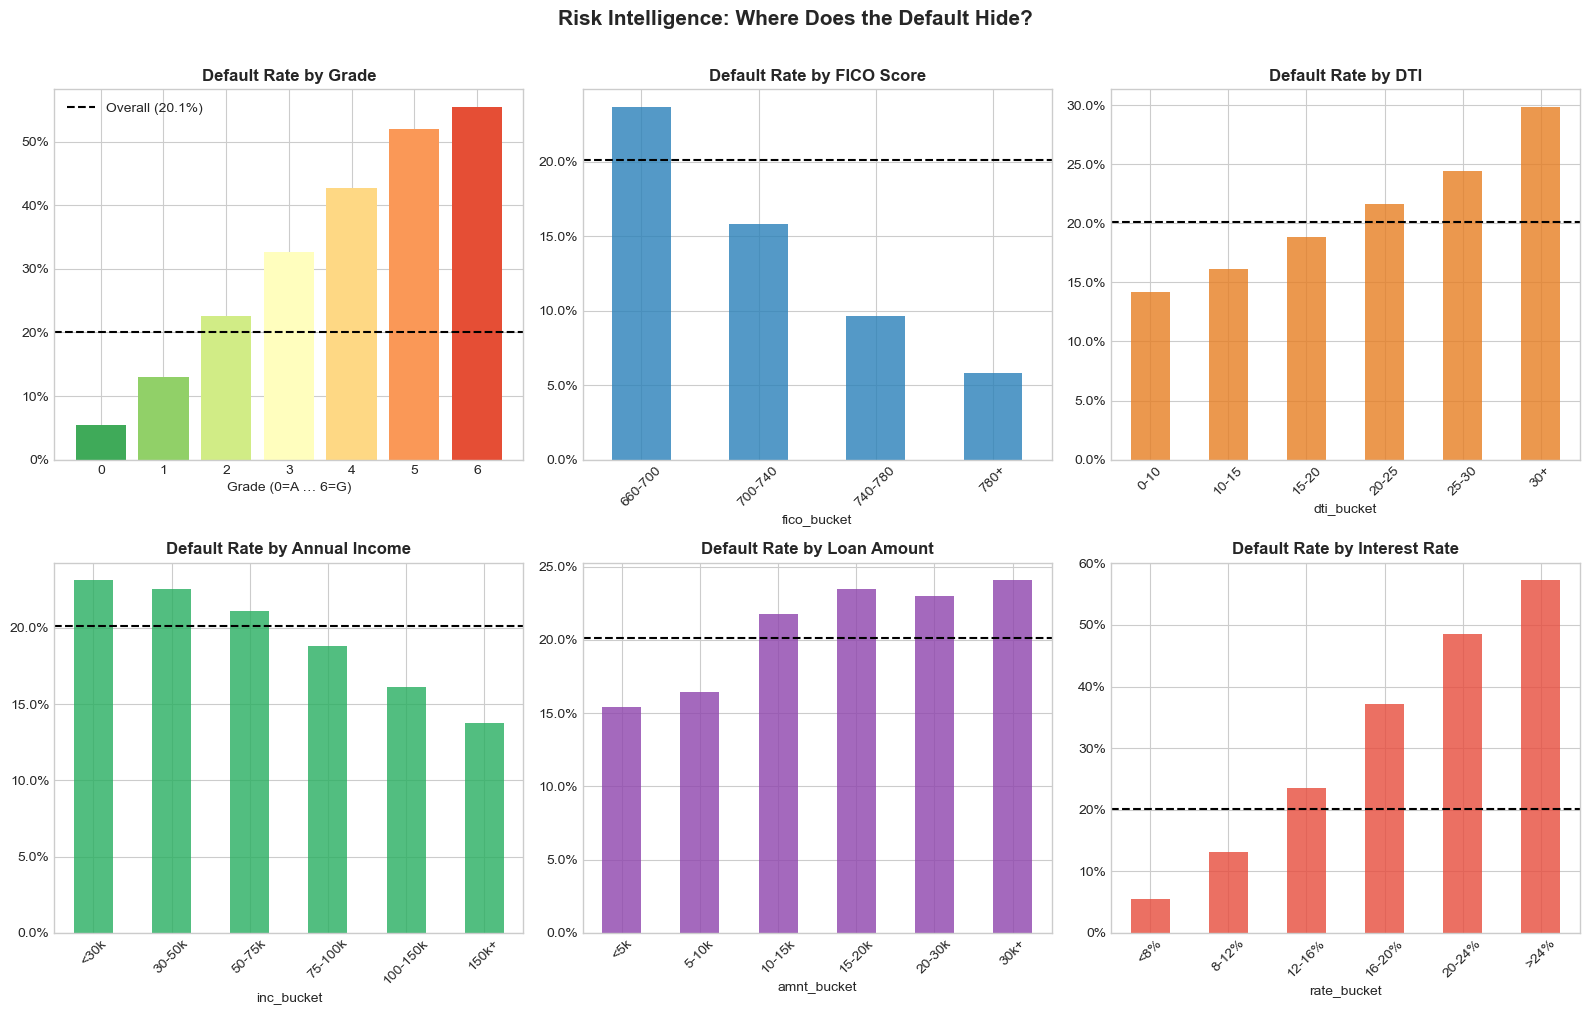

In [11]:
# ─── Default rate by grade ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Risk Intelligence: Where Does the Default Hide?',
             fontsize=15, fontweight='bold', y=1.01)

# 1. Default rate by grade
ax = axes[0, 0]
grade_stats = df_clean.groupby('grade_num')['default'].agg(['mean', 'count'])
bars = ax.bar(grade_stats.index, grade_stats['mean'],
              color=plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(grade_stats))))
ax.axhline(dr, color='black', linestyle='--', linewidth=1.5, label=f'Overall ({dr:.1%})')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel('Grade (0=A … 6=G)')
ax.set_title('Default Rate by Grade', fontweight='bold')
ax.legend()

# 2. Default rate by FICO bucket
ax = axes[0, 1]
df_clean['fico_bucket'] = pd.cut(df_clean['fico'], bins=[580, 620, 660, 700, 740, 780, 850],
                                  labels=['580-620','620-660','660-700','700-740','740-780','780+'])
fico_def = df_clean.groupby('fico_bucket', observed=True)['default'].mean()
fico_def.plot(kind='bar', ax=ax, color=C_BLUE, alpha=0.8, rot=45)
ax.axhline(dr, color='black', linestyle='--', linewidth=1.5)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Default Rate by FICO Score', fontweight='bold')

# 3. Default rate by DTI bucket
ax = axes[0, 2]
df_clean['dti_bucket'] = pd.cut(df_clean['dti'].clip(0, 50),
                                 bins=[0, 10, 15, 20, 25, 30, 50],
                                 labels=['0-10','10-15','15-20','20-25','25-30','30+'])
dti_def = df_clean.groupby('dti_bucket', observed=True)['default'].mean()
dti_def.plot(kind='bar', ax=ax, color=C_ORANGE, alpha=0.8, rot=45)
ax.axhline(dr, color='black', linestyle='--', linewidth=1.5)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Default Rate by DTI', fontweight='bold')

# 4. Default rate by income bucket
ax = axes[1, 0]
df_clean['inc_bucket'] = pd.cut(df_clean['annual_inc'].clip(0, 250_000),
                                 bins=[0, 30000, 50000, 75000, 100000, 150000, 250000],
                                 labels=['<30k','30-50k','50-75k','75-100k','100-150k','150k+'])
inc_def = df_clean.groupby('inc_bucket', observed=True)['default'].mean()
inc_def.plot(kind='bar', ax=ax, color=C_GREEN, alpha=0.8, rot=45)
ax.axhline(dr, color='black', linestyle='--', linewidth=1.5)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Default Rate by Annual Income', fontweight='bold')

# 5. Default rate by loan amount bucket
ax = axes[1, 1]
df_clean['amnt_bucket'] = pd.cut(df_clean['loan_amnt'],
                                  bins=[0, 5000, 10000, 15000, 20000, 30000, 40000],
                                  labels=['<5k','5-10k','10-15k','15-20k','20-30k','30k+'])
amnt_def = df_clean.groupby('amnt_bucket', observed=True)['default'].mean()
amnt_def.plot(kind='bar', ax=ax, color=C_PURPLE, alpha=0.8, rot=45)
ax.axhline(dr, color='black', linestyle='--', linewidth=1.5)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Default Rate by Loan Amount', fontweight='bold')

# 6. Default rate by int_rate bucket
ax = axes[1, 2]
df_clean['rate_bucket'] = pd.cut(df_clean['int_rate'],
                                  bins=[0, 8, 12, 16, 20, 24, 32],
                                  labels=['<8%','8-12%','12-16%','16-20%','20-24%','>24%'])
rate_def = df_clean.groupby('rate_bucket', observed=True)['default'].mean()
rate_def.plot(kind='bar', ax=ax, color=C_RED, alpha=0.8, rot=45)
ax.axhline(dr, color='black', linestyle='--', linewidth=1.5)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Default Rate by Interest Rate', fontweight='bold')

plt.tight_layout()
plt.savefig('phase2_eda.png', dpi=150, bbox_inches='tight')
plt.show()

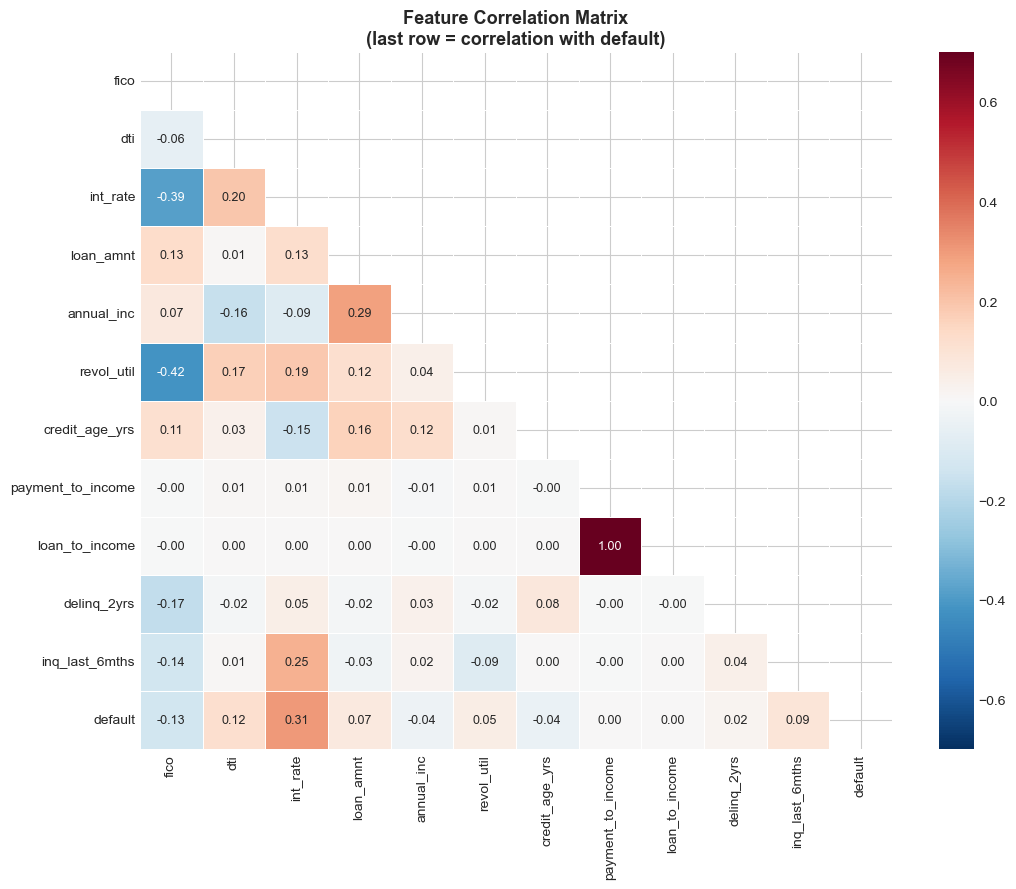


Top correlations with DEFAULT:
int_rate             0.305747
fico                -0.134564
dti                  0.115026
inq_last_6mths       0.090911
loan_amnt            0.067297
revol_util           0.053767
credit_age_yrs      -0.044544
annual_inc          -0.037386
delinq_2yrs          0.017207
payment_to_income    0.002884
loan_to_income       0.000160


In [12]:
# ─── Correlation heatmap ──────────────────────────────────────────────────────
num_features = ['fico', 'dti', 'int_rate', 'loan_amnt', 'annual_inc',
                'revol_util', 'credit_age_yrs', 'payment_to_income',
                'loan_to_income', 'delinq_2yrs', 'inq_last_6mths', 'default']

corr = df_clean[num_features].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-0.7, vmax=0.7, ax=ax,
            annot_kws={'size': 9}, linewidths=0.5)
ax.set_title('Feature Correlation Matrix\n(last row = correlation with default)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('phase2_corr.png', dpi=150, bbox_inches='tight')
plt.show()

# Key correlations with default
print('\nTop correlations with DEFAULT:')
print(corr['default'].drop('default').sort_values(key=abs, ascending=False).to_string())

In [13]:
# ─── Business insights ────────────────────────────────────────────────────────
print('='*60)
print('PHASE 2 RISK INTELLIGENCE — KEY FINDINGS')
print('='*60)

fico_breakpoint = df_clean.groupby('fico_bucket', observed=True)['default'].mean()
dti_high = df_clean[df_clean['dti'] > 25]['default'].mean()
dti_low  = df_clean[df_clean['dti'] <= 15]['default'].mean()
grade_g_dr = df_clean[df_clean['grade_num'] == 6]['default'].mean()
grade_a_dr = df_clean[df_clean['grade_num'] == 0]['default'].mean()

print(f"""
  FICO: Borrowers with FICO > 740 default at {fico_breakpoint.get('740-780', 0):.1%},
        vs {fico_breakpoint.get('580-620', 0):.1%} for FICO 580-620.

  DTI:  DTI > 25% → default rate {dti_high:.1%}  |  DTI < 15% → {dti_low:.1%}

  Grade: Grade A defaults {grade_a_dr:.1%},  Grade G defaults {grade_g_dr:.1%}

  Rate: Higher-rate loans carry significantly higher default rates,
        but also higher interest income — the profit engine must weigh both.

  Income: Higher-income borrowers default less, but income alone is insufficient.
          DTI captures leverage relative to income better.
""")

PHASE 2 RISK INTELLIGENCE — KEY FINDINGS

  FICO: Borrowers with FICO > 740 default at 9.6%,
        vs 0.0% for FICO 580-620.

  DTI:  DTI > 25% → default rate 27.0%  |  DTI < 15% → 15.3%

  Grade: Grade A defaults 5.4%,  Grade G defaults 55.4%

  Rate: Higher-rate loans carry significantly higher default rates,
        but also higher interest income — the profit engine must weigh both.

  Income: Higher-income borrowers default less, but income alone is insufficient.
          DTI captures leverage relative to income better.



---
# 🔵 PHASE 3 — Baseline Rule System
**Simple underwriting rules. This is the benchmark every ML model must beat.**

In [14]:
def evaluate_rule(df, rule_mask, rule_name, lgd=LGD, opex=OPEX_RATE):
    """Evaluate a rule-based approval policy and return business metrics."""
    approved = df[rule_mask].copy()
    n_total  = len(df)
    n_approved = len(approved)

    if n_approved == 0:
        return {'Rule': rule_name, 'Approval Rate': '0%'}

    # Realised profit on actual outcomes
    good = approved[approved['default'] == 0]
    bad  = approved[approved['default'] == 1]

    r = good['int_rate'] / 100
    t = good['term_months'] / 12
    interest_income = (good['loan_amnt'] * r * t).sum()
    default_loss    = (bad['loan_amnt'] * lgd).sum()
    total_opex      = (approved['loan_amnt'] * opex).sum()
    realized_profit = interest_income - default_loss - total_opex

    total_principal = approved['loan_amnt'].sum()
    roi = realized_profit / total_principal

    return {
        'Rule': rule_name,
        'Approval Rate':  f'{n_approved/n_total:.1%}',
        'Loans Approved': f'{n_approved:,}',
        'Default Rate':   f'{approved["default"].mean():.1%}',
        'Principal ($M)': f'{total_principal/1e6:.2f}',
        'Profit ($M)':    f'{realized_profit/1e6:.2f}',
        'Portfolio ROI':  f'{roi:.2%}'
    }

# ─── Define rules ────────────────────────────────────────────────────────────
# Approve all — upper bound on volume
r_all = pd.Series(True, index=df_clean.index)

# Conservative: high FICO + low DTI
r_conservative = (df_clean['fico'] >= 700) & (df_clean['dti'] <= 20)

# Moderate: FICO threshold only
r_moderate = (df_clean['fico'] >= 680) & (df_clean['dti'] <= 30)

# Aggressive: any grade A-C
r_aggressive = df_clean['grade_num'] <= 2

results = [
    evaluate_rule(df_clean, r_all,         'Approve All'),
    evaluate_rule(df_clean, r_aggressive,  'Grade A-C only'),
    evaluate_rule(df_clean, r_moderate,    'FICO≥680 & DTI≤30%'),
    evaluate_rule(df_clean, r_conservative,'FICO≥700 & DTI≤20%'),
]

benchmark_df = pd.DataFrame(results).set_index('Rule')
print('='*80)
print('PHASE 3 — BASELINE RULE SYSTEM BENCHMARK')
print('='*80)
print(benchmark_df.T.to_string())

PHASE 3 — BASELINE RULE SYSTEM BENCHMARK
Rule           Approve All Grade A-C only FICO≥680 & DTI≤30% FICO≥700 & DTI≤20%
Approval Rate       100.0%          76.2%              55.7%              21.1%
Loans Approved     265,777        202,633            148,019             55,977
Default Rate         20.1%          14.6%              15.8%              11.1%
Principal ($M)     3874.79        2822.95            2313.05             898.53
Profit ($M)         610.11         468.32             422.34             182.97
Portfolio ROI       15.75%         16.59%             18.26%             20.36%


In [15]:
# Save benchmark for comparison in Phase 5
BEST_RULE_NAME = 'FICO≥680 & DTI≤30%'
BEST_RULE_MASK = r_moderate

best_rule_profit = float(benchmark_df.loc[BEST_RULE_NAME, 'Profit ($M)'])
best_rule_roi    = benchmark_df.loc[BEST_RULE_NAME, 'Portfolio ROI']
print(f'\nBenchmark to beat: {BEST_RULE_NAME}')
print(f'  Profit: ${best_rule_profit:.2f}M  |  ROI: {best_rule_roi}')


Benchmark to beat: FICO≥680 & DTI≤30%
  Profit: $422.34M  |  ROI: 18.26%


---
# 🔵 PHASE 4 — Machine Learning Risk Model
**Predict Probability of Default (PD). The model predicts risk — the decision engine converts it to money.**

In [16]:
# ─── Train / Test split ───────────────────────────────────────────────────────
X = df_clean[FEATURE_COLS]
y = df_clean['default']
fin = df_clean[FINANCIAL_COLS + ['monthly_inc']]

X_tr, X_te, y_tr, y_te, fin_tr, fin_te = train_test_split(
    X, y, fin, test_size=0.2, stratify=y, random_state=SEED
)
print(f'Train: {X_tr.shape[0]:,}  |  Test: {X_te.shape[0]:,}')
print(f'Train default rate: {y_tr.mean():.2%}  |  Test: {y_te.mean():.2%}')

Train: 212,621  |  Test: 53,156
Train default rate: 20.13%  |  Test: 20.13%


In [17]:
# ─── Model 1: Logistic Regression (baseline) ─────────────────────────────────
print('Training Logistic Regression...')
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(class_weight='balanced', C=0.05,
                              max_iter=500, random_state=SEED))
])
lr_pipe.fit(X_tr, y_tr)
lr_probs = lr_pipe.predict_proba(X_te)[:, 1]
lr_auc = roc_auc_score(y_te, lr_probs)
print(f'✅  Logistic Regression AUC: {lr_auc:.4f}')

Training Logistic Regression...
✅  Logistic Regression AUC: 0.7278


In [18]:
# ─── Model 2: Random Forest ───────────────────────────────────────────────────
print('Training Random Forest...')
rf = RandomForestClassifier(
    n_estimators=200, max_depth=8, min_samples_leaf=50,
    class_weight='balanced', n_jobs=-1, random_state=SEED
)
rf_calibrated = CalibratedClassifierCV(rf, method='isotonic', cv=3)
rf_calibrated.fit(X_tr, y_tr)
rf_probs = rf_calibrated.predict_proba(X_te)[:, 1]
rf_auc = roc_auc_score(y_te, rf_probs)
print(f'✅  Random Forest AUC: {rf_auc:.4f}')

Training Random Forest...
✅  Random Forest AUC: 0.7349


In [19]:
# ─── Model 3: Gradient Boosting (primary) ────────────────────────────────────
print('Training Gradient Boosting (this takes ~2 min)...')
gbc = GradientBoostingClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, min_samples_leaf=50,
    validation_fraction=0.1, n_iter_no_change=15,
    random_state=SEED
)
gbc_calibrated = CalibratedClassifierCV(gbc, method='sigmoid', cv=3)
gbc_calibrated.fit(X_tr, y_tr)
gbc_probs = gbc_calibrated.predict_proba(X_te)[:, 1]
gbc_auc = roc_auc_score(y_te, gbc_probs)
print(f'✅  Gradient Boosting AUC: {gbc_auc:.4f}')

# Primary model for Phase 5+
BEST_MODEL  = gbc_calibrated
BEST_PROBS  = gbc_probs
BEST_AUC    = gbc_auc

Training Gradient Boosting (this takes ~2 min)...
✅  Gradient Boosting AUC: 0.7463


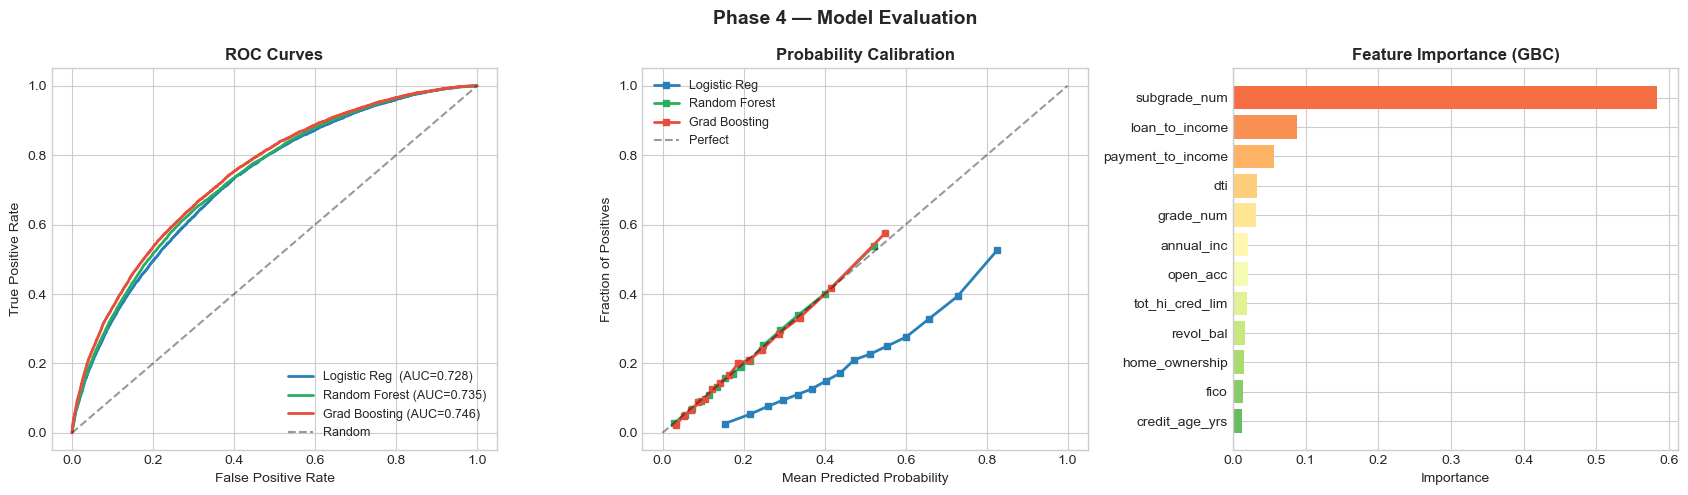


Model Summary:
  Logistic Regression : AUC = 0.7278
  Random Forest       : AUC = 0.7349
  Gradient Boosting   : AUC = 0.7463  ← selected


In [20]:
# ─── Evaluation plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Phase 4 — Model Evaluation', fontsize=14, fontweight='bold')

# ROC
ax = axes[0]
for probs, label, color in [
    (lr_probs,  f'Logistic Reg  (AUC={lr_auc:.3f})',  C_BLUE),
    (rf_probs,  f'Random Forest (AUC={rf_auc:.3f})',  C_GREEN),
    (gbc_probs, f'Grad Boosting (AUC={gbc_auc:.3f})', C_RED),
]:
    fpr, tpr, _ = roc_curve(y_te, probs)
    ax.plot(fpr, tpr, label=label, linewidth=2, color=color)
ax.plot([0,1],[0,1],'k--',alpha=0.4,label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves', fontweight='bold')
ax.legend(fontsize=9)

# Calibration
ax = axes[1]
for probs, label, color in [
    (lr_probs,  'Logistic Reg',  C_BLUE),
    (rf_probs,  'Random Forest', C_GREEN),
    (gbc_probs, 'Grad Boosting', C_RED),
]:
    fp, mp = calibration_curve(y_te, probs, n_bins=15, strategy='quantile')
    ax.plot(mp, fp, 's-', label=label, linewidth=2, color=color, markersize=5)
ax.plot([0,1],[0,1],'k--',alpha=0.4,label='Perfect')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Probability Calibration', fontweight='bold')
ax.legend(fontsize=9)

# Feature importance
ax = axes[2]
importances = np.zeros(len(FEATURE_COLS))
for clf in gbc_calibrated.calibrated_classifiers_:
    importances += clf.estimator.feature_importances_
importances /= len(gbc_calibrated.calibrated_classifiers_)
imp_df = pd.DataFrame({'Feature': FEATURE_COLS, 'Importance': importances})
imp_df = imp_df.sort_values('Importance', ascending=True).tail(12)
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(imp_df)))
ax.barh(imp_df['Feature'], imp_df['Importance'], color=colors)
ax.set_xlabel('Importance')
ax.set_title('Feature Importance (GBC)', fontweight='bold')

plt.tight_layout()
plt.savefig('phase4_models.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nModel Summary:')
print(f'  Logistic Regression : AUC = {lr_auc:.4f}')
print(f'  Random Forest       : AUC = {rf_auc:.4f}')
print(f'  Gradient Boosting   : AUC = {gbc_auc:.4f}  ← selected')

---
# 🔵 PHASE 5 — Decision Intelligence Layer
**The core differentiator. Convert PD → Expected Profit → Approval Decision.**

In [21]:
# ─── Build test results dataframe ─────────────────────────────────────────────
res = fin_te.copy()
res['p_default']      = BEST_PROBS
res['actual_default'] = y_te.values

# Per-loan expected profit and break-even threshold
res['exp_profit'] = expected_profit(
    res['p_default'], res['loan_amnt'], res['int_rate'], res['term_months']
)
res['breakeven_pd'] = res.apply(
    lambda r: breakeven_pd(r['int_rate'], r['term_months']), axis=1
)

# Profit-optimised decision: approve if E[profit] > 0
res['approved_profit_opt'] = (res['exp_profit'] > 0).astype(int)

# Baseline decisions
res['approved_fixed_50'] = (res['p_default'] < 0.50).astype(int)
res['approved_fixed_20'] = (res['p_default'] < 0.20).astype(int)

# Rule-based decision (apply Phase 3 rule to test rows)
test_clean_rows = df_clean.loc[X_te.index]
res['approved_rule'] = (BEST_RULE_MASK.loc[X_te.index]).astype(int).values

print('Decisions computed. Approval rates:')
for col, label in [
    ('approved_profit_opt', 'Profit-Optimised'),
    ('approved_fixed_50',   'Fixed 0.50'),
    ('approved_fixed_20',   'Fixed 0.20'),
    ('approved_rule',       'Rule-Based'),
]:
    print(f'  {label:<22}: {res[col].mean():.1%}')

Decisions computed. Approval rates:
  Profit-Optimised      : 94.8%
  Fixed 0.50            : 94.9%
  Fixed 0.20            : 60.2%
  Rule-Based            : 55.8%


In [22]:
# ─── Full policy comparison ────────────────────────────────────────────────────
def policy_metrics(df_res, col, label):
    a = df_res[df_res[col] == 1]
    n = len(a)
    if n == 0:
        return {'Policy': label}
    principal = a['loan_amnt'].sum()
    good = a[a['actual_default'] == 0]
    bad  = a[a['actual_default'] == 1]
    r, t = good['int_rate']/100, good['term_months']/12
    profit = (good['loan_amnt']*r*t).sum() - (bad['loan_amnt']*LGD).sum() - principal*OPEX_RATE
    return {
        'Policy':           label,
        'Approval Rate':    f"{n/len(df_res):.1%}",
        '# Approved':       f"{n:,}",
        'Default Rate':     f"{a['actual_default'].mean():.1%}",
        'Principal ($M)':   f"{principal/1e6:.2f}",
        'Profit ($M)':      f"{profit/1e6:.2f}",
        'ROI':              f"{profit/principal:.2%}"
    }

policies = [
    ('approved_profit_opt', '✅ Profit-Optimised (ours)'),
    ('approved_fixed_50',   'Fixed Threshold 0.50'),
    ('approved_fixed_20',   'Fixed Threshold 0.20'),
    ('approved_rule',       'Rule-Based Baseline'),
]
comp = pd.DataFrame([policy_metrics(res, c, l) for c, l in policies]).set_index('Policy')

print('='*75)
print('PHASE 5 — POLICY COMPARISON')
print('='*75)
print(comp.T.to_string())

PHASE 5 — POLICY COMPARISON
Policy         ✅ Profit-Optimised (ours) Fixed Threshold 0.50 Fixed Threshold 0.20 Rule-Based Baseline
Approval Rate                      94.8%                94.9%                60.2%               55.8%
# Approved                        50,384               50,433               31,985              29,656
Default Rate                       18.2%                18.0%                10.7%               15.7%
Principal ($M)                    727.64               721.68               432.79              462.84
Profit ($M)                       126.23               125.16                76.96               85.02
ROI                               17.35%               17.34%               17.78%              18.37%


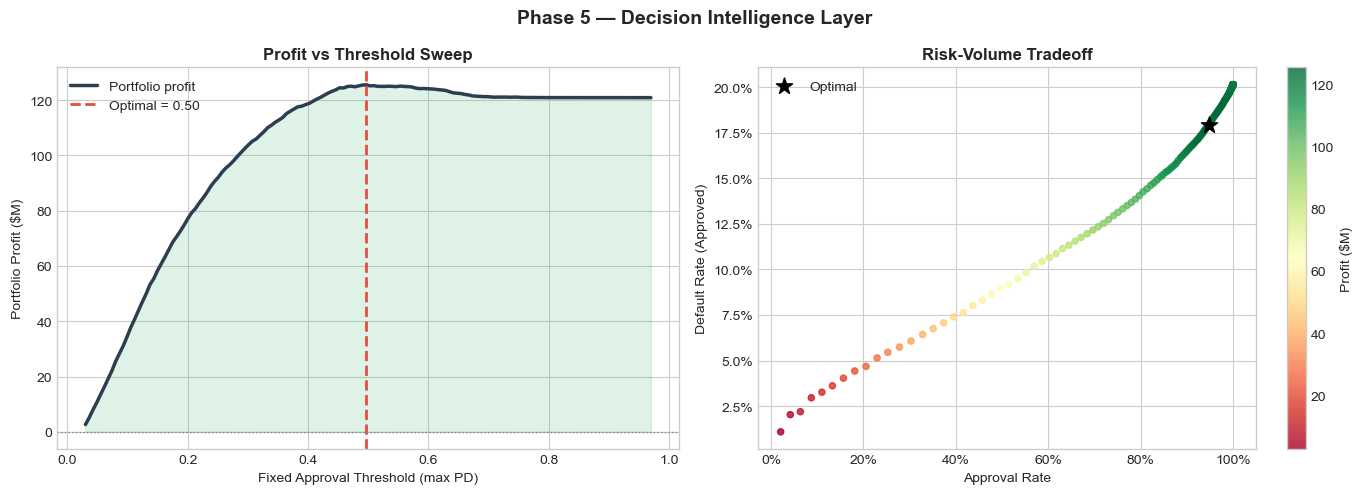

Globally optimal FIXED threshold : 0.497
Max profit at optimal threshold  : $125.51M
Profit-optimised (per-loan) policy: see table above


In [23]:
# ─── Profit curve: sweep threshold from 0 to 1 ────────────────────────────────
thresholds = np.linspace(0.03, 0.97, 150)
profits, approval_rates, default_rates = [], [], []

for t in thresholds:
    a = res[res['p_default'] < t]
    if len(a) == 0:
        profits.append(0); approval_rates.append(0); default_rates.append(0)
        continue
    good, bad = a[a['actual_default']==0], a[a['actual_default']==1]
    r2, t2 = good['int_rate']/100, good['term_months']/12
    p = (good['loan_amnt']*r2*t2).sum() - (bad['loan_amnt']*LGD).sum() - a['loan_amnt'].sum()*OPEX_RATE
    profits.append(p/1e6)
    approval_rates.append(len(a)/len(res))
    default_rates.append(a['actual_default'].mean())

opt_idx   = np.argmax(profits)
opt_thresh = thresholds[opt_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Phase 5 — Decision Intelligence Layer', fontsize=14, fontweight='bold')

# Profit curve
ax = axes[0]
ax.plot(thresholds, profits, color=C_DARK, linewidth=2.5, label='Portfolio profit')
ax.axvline(opt_thresh, color=C_RED, linestyle='--', linewidth=2,
           label=f'Optimal = {opt_thresh:.2f}')
ax.axhline(0, color='gray', linestyle=':', linewidth=1)
ax.fill_between(thresholds, profits, 0,
                where=np.array(profits)>0, alpha=0.15, color=C_GREEN)
ax.fill_between(thresholds, profits, 0,
                where=np.array(profits)<=0, alpha=0.15, color=C_RED)
ax.set_xlabel('Fixed Approval Threshold (max PD)')
ax.set_ylabel('Portfolio Profit ($M)')
ax.set_title('Profit vs Threshold Sweep', fontweight='bold')
ax.legend()

# Risk-volume tradeoff
ax = axes[1]
sc = ax.scatter(approval_rates, default_rates, c=profits,
                cmap='RdYlGn', s=20, alpha=0.8)
ax.scatter([approval_rates[opt_idx]], [default_rates[opt_idx]],
           color='black', s=150, zorder=5, marker='*', label=f'Optimal')
plt.colorbar(sc, ax=ax, label='Profit ($M)')
ax.set_xlabel('Approval Rate')
ax.set_ylabel('Default Rate (Approved)')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Risk-Volume Tradeoff', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('phase5_decision.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Globally optimal FIXED threshold : {opt_thresh:.3f}')
print(f'Max profit at optimal threshold  : ${max(profits):.2f}M')
print(f'Profit-optimised (per-loan) policy: see table above')

---
# 🔵 PHASE 6 — Portfolio Optimization
**Capital is finite. Rank all loans by expected profit and allocate greedily.**

In [24]:
# ─── Greedy capital allocation ────────────────────────────────────────────────
# Rank ALL test loans by expected profit (highest first)
portfolio = res.copy()
portfolio = portfolio.sort_values('exp_profit', ascending=False).reset_index(drop=True)

# Cumulative capital deployment
portfolio['cum_capital'] = portfolio['loan_amnt'].cumsum()

# Two constraints: max loans OR max capital
mask_loan_limit    = portfolio.index < MAX_PORTFOLIO_LOANS
mask_capital_limit = portfolio['cum_capital'] <= MAX_PORTFOLIO_CAPITAL
mask_profitable    = portfolio['exp_profit'] > 0  # only profitable loans

# Combined constraint
approved_portfolio = portfolio[
    mask_loan_limit & mask_capital_limit & mask_profitable
]

def portfolio_summary(df_port, label):
    if len(df_port) == 0:
        return {'Portfolio': label}
    good = df_port[df_port['actual_default'] == 0]
    bad  = df_port[df_port['actual_default'] == 1]
    principal = df_port['loan_amnt'].sum()
    r, t = good['int_rate']/100, good['term_months']/12
    profit = (good['loan_amnt']*r*t).sum() - (bad['loan_amnt']*LGD).sum() - principal*OPEX_RATE
    return {
        'Portfolio':       label,
        '# Loans':         f"{len(df_port):,}",
        'Capital ($M)':    f"{principal/1e6:.2f}",
        'Avg Loan ($)':    f"{df_port['loan_amnt'].mean():,.0f}",
        'Avg PD':          f"{df_port['p_default'].mean():.2%}",
        'Actual Default':  f"{df_port['actual_default'].mean():.1%}",
        'Profit ($M)':     f"{profit/1e6:.2f}",
        'ROI':             f"{profit/principal:.2%}",
        'Profit/Loan ($)': f"{profit/len(df_port):,.0f}"
    }

# Compare: top-N unconstrained vs capital-constrained portfolio
top_n_unconstrained = portfolio[mask_profitable].head(MAX_PORTFOLIO_LOANS)

port_results = pd.DataFrame([
    portfolio_summary(approved_portfolio,    f'Capital-Constrained (≤$50M, ≤{MAX_PORTFOLIO_LOANS:,} loans)'),
    portfolio_summary(top_n_unconstrained,   f'Top-{MAX_PORTFOLIO_LOANS:,} by Expected Profit'),
    portfolio_summary(portfolio[mask_profitable], 'All Profitable Loans'),
]).set_index('Portfolio')

print('='*80)
print('PHASE 6 — PORTFOLIO OPTIMIZATION')
print('='*80)
print(port_results.T.to_string())

PHASE 6 — PORTFOLIO OPTIMIZATION
Portfolio       Capital-Constrained (≤$50M, ≤2,000 loans) Top-2,000 by Expected Profit All Profitable Loans
# Loans                                             1,604                        2,000               50,384
Capital ($M)                                        49.98                        61.19               727.64
Avg Loan ($)                                       31,158                       30,595               14,442
Avg PD                                             23.26%                       22.79%               18.32%
Actual Default                                      23.8%                        23.4%                18.2%
Profit ($M)                                         17.77                        20.81               126.23
ROI                                                35.55%                       34.02%               17.35%
Profit/Loan ($)                                    11,077                       10,407                2

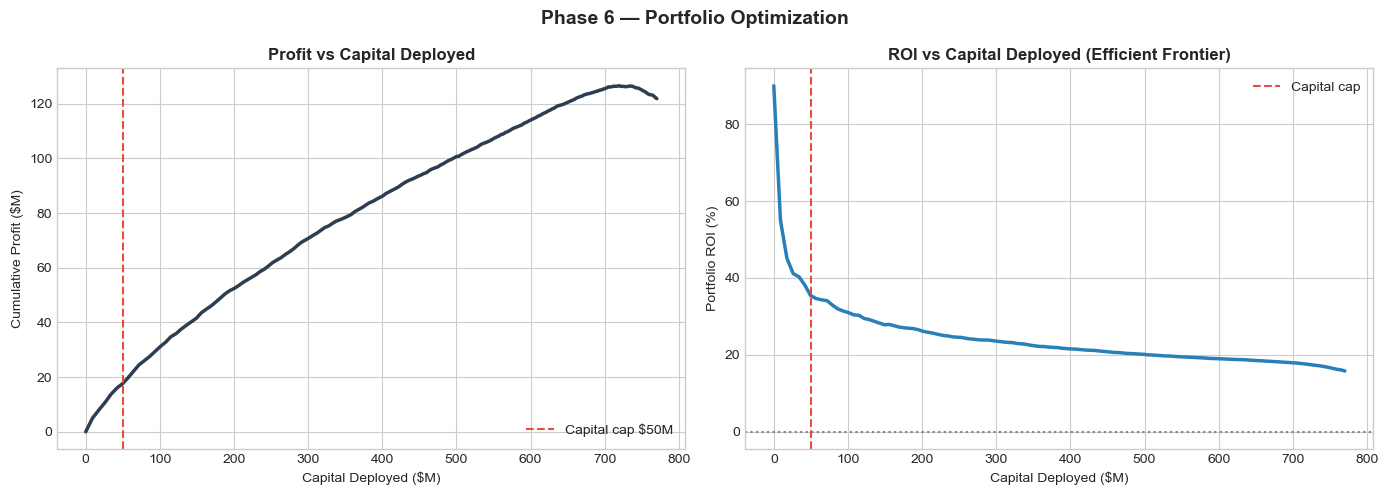

Insight: ROI decreases as capital increases — marginal loans are less profitable.
The optimal portfolio is at the elbow of the efficient frontier.


In [25]:
# ─── Efficient Frontier: profit vs capital deployed ───────────────────────────
# As we deploy more capital (lower expected-profit threshold), what happens to ROI?
portfolio_sorted = portfolio.sort_values('exp_profit', ascending=False).reset_index(drop=True)
portfolio_sorted['cum_capital_M'] = portfolio_sorted['loan_amnt'].cumsum() / 1e6

cum_profits = []
for i in range(0, len(portfolio_sorted), max(1, len(portfolio_sorted)//200)):
    sub = portfolio_sorted.iloc[:i+1]
    good, bad = sub[sub['actual_default']==0], sub[sub['actual_default']==1]
    r2, t2 = good['int_rate']/100, good['term_months']/12
    p = (good['loan_amnt']*r2*t2).sum() - (bad['loan_amnt']*LGD).sum() - sub['loan_amnt'].sum()*OPEX_RATE
    cum_profits.append((sub['cum_capital_M'].iloc[-1], p/1e6, p/sub['loan_amnt'].sum()))

eff_df = pd.DataFrame(cum_profits, columns=['Capital_M', 'Profit_M', 'ROI'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Phase 6 — Portfolio Optimization', fontsize=14, fontweight='bold')

axes[0].plot(eff_df['Capital_M'], eff_df['Profit_M'], color=C_DARK, linewidth=2.5)
axes[0].axvline(MAX_PORTFOLIO_CAPITAL/1e6, color=C_RED, linestyle='--',
               label=f'Capital cap ${MAX_PORTFOLIO_CAPITAL/1e6:.0f}M')
axes[0].set_xlabel('Capital Deployed ($M)')
axes[0].set_ylabel('Cumulative Profit ($M)')
axes[0].set_title('Profit vs Capital Deployed', fontweight='bold')
axes[0].legend()

axes[1].plot(eff_df['Capital_M'], eff_df['ROI']*100, color=C_BLUE, linewidth=2.5)
axes[1].axhline(0, color='gray', linestyle=':')
axes[1].axvline(MAX_PORTFOLIO_CAPITAL/1e6, color=C_RED, linestyle='--',
               label=f'Capital cap')
axes[1].set_xlabel('Capital Deployed ($M)')
axes[1].set_ylabel('Portfolio ROI (%)')
axes[1].set_title('ROI vs Capital Deployed (Efficient Frontier)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('phase6_portfolio.png', dpi=150, bbox_inches='tight')
plt.show()

print('Insight: ROI decreases as capital increases — marginal loans are less profitable.')
print('The optimal portfolio is at the elbow of the efficient frontier.')

---
# 🔵 PHASE 7 — Stress Testing
**Does the profit survive economic shocks? Simulate 3 macro scenarios.**

In [26]:
def stress_profit(df_approved, lgd_mult=1.0, default_rate_mult=1.0, rate_reduction=0.0,
                  opex=OPEX_RATE):
    """
    Compute realised portfolio profit under a stressed scenario.
    
    Parameters
    ----------
    lgd_mult          : multiply LGD by this factor (1.0 = base case)
    default_rate_mult : multiply actual default rate by this factor
    rate_reduction    : subtract this from int_rate (interest rate compression)
    """
    port = df_approved.copy()
    
    # Stressed default: randomly flip some non-defaulters to defaulters
    rng = np.random.RandomState(SEED)
    if default_rate_mult > 1.0:
        good_idx = port[port['actual_default'] == 0].index
        base_dr = port['actual_default'].mean()
        new_dr  = min(base_dr * default_rate_mult, 0.99)
        extra   = int((new_dr - base_dr) * len(port))
        if extra > 0 and len(good_idx) > 0:
            flip_idx = rng.choice(good_idx, size=min(extra, len(good_idx)), replace=False)
            port.loc[flip_idx, 'actual_default'] = 1

    stressed_rate = (port['int_rate'] - rate_reduction).clip(lower=0)
    stressed_lgd  = min(LGD * lgd_mult, 1.0)

    good = port[port['actual_default'] == 0]
    bad  = port[port['actual_default'] == 1]
    r2   = stressed_rate.loc[good.index] / 100
    t2   = good['term_months'] / 12
    principal = port['loan_amnt'].sum()
    
    profit = (
        (good['loan_amnt'] * r2 * t2).sum()
        - (bad['loan_amnt'] * stressed_lgd).sum()
        - principal * opex
    )
    return profit / 1e6


approved_port = res[res['approved_profit_opt'] == 1]

# ─── Define 3 scenarios ───────────────────────────────────────────────────────
SCENARIOS = [
    {
        'name': 'Base Case',
        'desc': 'Current conditions',
        'lgd_mult': 1.0, 'dr_mult': 1.0, 'rate_cut': 0.0
    },
    {
        'name': 'Mild Recession',
        'desc': '+20% defaults, LGD +10%',
        'lgd_mult': 1.1, 'dr_mult': 1.2, 'rate_cut': 0.0
    },
    {
        'name': 'Severe Recession',
        'desc': '+40% defaults, LGD +20%, rates -2%',
        'lgd_mult': 1.2, 'dr_mult': 1.4, 'rate_cut': 2.0
    },
    {
        'name': 'Extreme Stress',
        'desc': '+80% defaults (2008-style), LGD +30%',
        'lgd_mult': 1.3, 'dr_mult': 1.8, 'rate_cut': 0.0
    },
    {
        'name': 'Rate Compression',
        'desc': 'Rates fall -5% (refi wave)',
        'lgd_mult': 1.0, 'dr_mult': 0.9, 'rate_cut': 5.0
    },
]

stress_results = []
base_profit = None
for s in SCENARIOS:
    p = stress_profit(approved_port,
                      lgd_mult=s['lgd_mult'],
                      default_rate_mult=s['dr_mult'],
                      rate_reduction=s['rate_cut'])
    if s['name'] == 'Base Case':
        base_profit = p
    stress_results.append({
        'Scenario': s['name'],
        'Description': s['desc'],
        'Profit ($M)': round(p, 2),
        '% Change': f"{(p-base_profit)/abs(base_profit)*100:.1f}%" if base_profit else 'N/A',
        'Profitable?': '✅ Yes' if p > 0 else '❌ No'
    })

stress_df = pd.DataFrame(stress_results).set_index('Scenario')
print('='*65)
print('PHASE 7 — STRESS TEST RESULTS')
print('='*65)
print(stress_df.to_string())

PHASE 7 — STRESS TEST RESULTS
                                           Description  Profit ($M) % Change Profitable?
Scenario                                                                                
Base Case                           Current conditions       126.23     0.0%       ✅ Yes
Mild Recession                 +20% defaults, LGD +10%        81.21   -35.7%       ✅ Yes
Severe Recession    +40% defaults, LGD +20%, rates -2%        -6.63  -105.2%        ❌ No
Extreme Stress    +80% defaults (2008-style), LGD +30%       -50.96  -140.4%        ❌ No
Rate Compression            Rates fall -5% (refi wave)        23.35   -81.5%       ✅ Yes


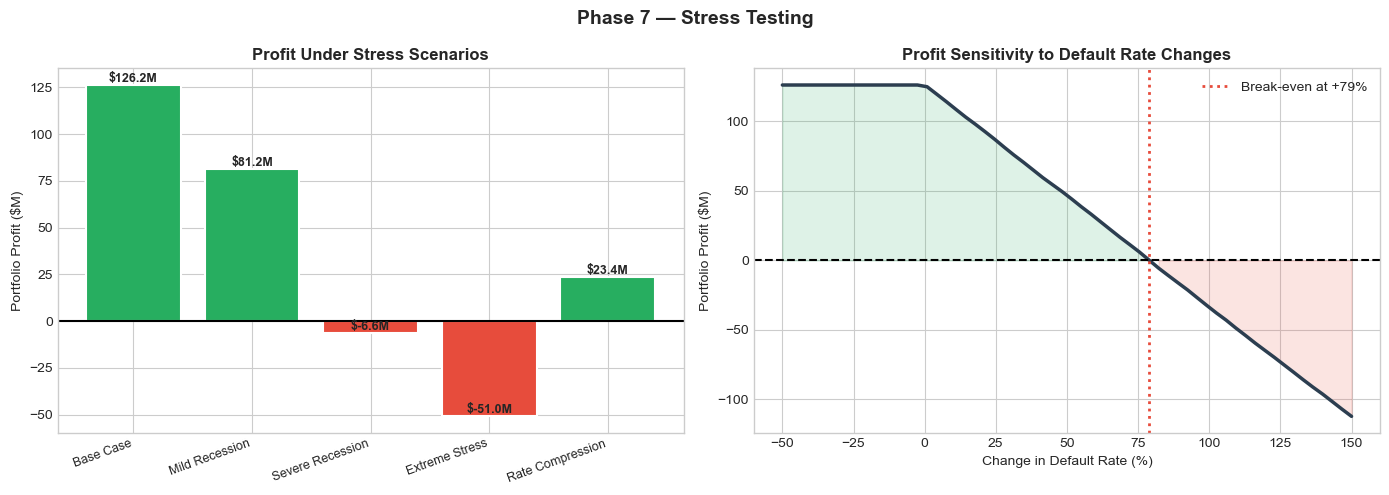

Portfolio remains profitable until default rates increase by ~79%


In [27]:
# ─── Stress test visualisation ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Phase 7 — Stress Testing', fontsize=14, fontweight='bold')

# Bar chart of profits by scenario
ax = axes[0]
scenario_names = stress_df.index.tolist()
profits_vals   = stress_df['Profit ($M)'].values
bar_colors = [C_GREEN if p > 0 else C_RED for p in profits_vals]
bars = ax.bar(range(len(scenario_names)), profits_vals, color=bar_colors, edgecolor='white', linewidth=1.5)
ax.axhline(0, color='black', linewidth=1.5)
ax.set_xticks(range(len(scenario_names)))
ax.set_xticklabels(scenario_names, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Portfolio Profit ($M)')
ax.set_title('Profit Under Stress Scenarios', fontweight='bold')
for bar, p in zip(bars, profits_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'${p:.1f}M', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Waterfall: default rate sensitivity
ax = axes[1]
dr_multipliers = np.linspace(0.5, 2.5, 60)
profit_sensitivity = [
    stress_profit(approved_port, lgd_mult=1.0, default_rate_mult=m, rate_reduction=0)
    for m in dr_multipliers
]
ax.plot(dr_multipliers * 100 - 100, profit_sensitivity, color=C_DARK, linewidth=2.5)
ax.axhline(0, color='black', linestyle='--', linewidth=1.5)
ax.fill_between(dr_multipliers*100-100, profit_sensitivity, 0,
                where=np.array(profit_sensitivity)>0, alpha=0.15, color=C_GREEN)
ax.fill_between(dr_multipliers*100-100, profit_sensitivity, 0,
                where=np.array(profit_sensitivity)<=0, alpha=0.15, color=C_RED)
ax.set_xlabel('Change in Default Rate (%)')
ax.set_ylabel('Portfolio Profit ($M)')
ax.set_title('Profit Sensitivity to Default Rate Changes', fontweight='bold')

# Mark break-even point
break_even_mult = np.interp(0, profit_sensitivity[::-1], (dr_multipliers*100-100)[::-1])
ax.axvline(break_even_mult, color=C_RED, linestyle=':', linewidth=2,
           label=f'Break-even at +{break_even_mult:.0f}%')
ax.legend()

plt.tight_layout()
plt.savefig('phase7_stress.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Portfolio remains profitable until default rates increase by ~{break_even_mult:.0f}%')

---
# 🔵 PHASE 8 — System Design
**Production-ready approval function. Input: applicant data. Output: decision + reasoning.**

In [28]:
class CreditApprovalEngine:
    """
    Profit-Optimized Credit Approval Engine
    
    Architecture:
        Applicant Data → Preprocessing → PD Model → Profit Engine
        → Threshold Check → APPROVE / DECLINE + Full Reasoning
    """

    def __init__(self, model, feature_cols, lgd=LGD, opex_rate=OPEX_RATE,
                 min_fico=580, max_dti=50, max_pd_override=0.45):
        self.model           = model
        self.feature_cols    = feature_cols
        self.lgd             = lgd
        self.opex_rate       = opex_rate
        self.min_fico        = min_fico       # hard floor — never approve below this FICO
        self.max_dti         = max_dti        # hard ceiling
        self.max_pd_override = max_pd_override # hard PD ceiling regardless of profit

    def preprocess(self, applicant: dict) -> pd.DataFrame:
        """Build a feature vector from raw applicant dict."""
        X = pd.DataFrame([applicant])
        for col in self.feature_cols:
            if col not in X.columns:
                X[col] = 0.0
        return X[self.feature_cols].astype(float)

    def predict_pd(self, X: pd.DataFrame) -> float:
        return float(self.model.predict_proba(X)[0, 1])

    def compute_profit(self, pd, loan_amnt, int_rate, term_months) -> float:
        return expected_profit(pd, loan_amnt, int_rate, term_months,
                               lgd=self.lgd, opex=self.opex_rate)

    def decide(self, applicant: dict) -> dict:
        """
        Make a full credit decision.

        Parameters
        ----------
        applicant : dict containing feature values + loan_amnt, int_rate, term_months

        Returns
        -------
        dict with decision, probability, expected_profit, and full reasoning
        """
        # Extract financial params
        loan_amnt   = applicant.get('loan_amnt', 0)
        int_rate    = applicant.get('int_rate', 0)
        term_months = applicant.get('term_months', 36)
        fico        = applicant.get('fico', 700)
        dti         = applicant.get('dti', 20)

        # Step 1: Predict PD
        X   = self.preprocess(applicant)
        pd_ = self.predict_pd(X)

        # Step 2: Compute expected profit
        exp_profit_val = self.compute_profit(pd_, loan_amnt, int_rate, term_months)

        # Step 3: Break-even threshold for this loan
        be_pd = breakeven_pd(int_rate, term_months, lgd=self.lgd, opex=self.opex_rate)

        # Step 4: Hard rule checks
        hard_decline_reasons = []
        if fico < self.min_fico:
            hard_decline_reasons.append(f'FICO {fico} < minimum {self.min_fico}')
        if dti > self.max_dti:
            hard_decline_reasons.append(f'DTI {dti:.1f}% > maximum {self.max_dti}%')
        if pd_ > self.max_pd_override:
            hard_decline_reasons.append(f'PD {pd_:.1%} > hard cap {self.max_pd_override:.0%}')

        # Step 5: Final decision
        if hard_decline_reasons:
            decision = 'DECLINE'
            reason   = 'Hard rule: ' + '; '.join(hard_decline_reasons)
        elif exp_profit_val > 0:
            decision = 'APPROVE'
            reason   = f'E[Profit]=${exp_profit_val:,.0f} > 0 (PD {pd_:.1%} < break-even {be_pd:.1%})'
        else:
            decision = 'DECLINE'
            reason   = f'E[Profit]=${exp_profit_val:,.0f} < 0 (PD {pd_:.1%} > break-even {be_pd:.1%})'

        # Step 6: Risk tier
        if pd_ < 0.10:
            risk_tier = 'LOW'
        elif pd_ < 0.20:
            risk_tier = 'MEDIUM'
        elif pd_ < 0.30:
            risk_tier = 'HIGH'
        else:
            risk_tier = 'VERY HIGH'

        return {
            'decision':           decision,
            'p_default':          round(pd_, 4),
            'breakeven_pd':       round(be_pd, 4),
            'margin_of_safety':   round(be_pd - pd_, 4),
            'expected_profit':    round(exp_profit_val, 2),
            'risk_tier':          risk_tier,
            'reason':             reason,
            'loan_amnt':          loan_amnt,
            'int_rate':           int_rate,
            'term_months':        term_months,
        }


# ─── Instantiate ──────────────────────────────────────────────────────────────
engine = CreditApprovalEngine(
    model=BEST_MODEL,
    feature_cols=FEATURE_COLS,
    lgd=LGD,
    opex_rate=OPEX_RATE
)
print('✅  CreditApprovalEngine instantiated.')

✅  CreditApprovalEngine instantiated.


In [29]:
# ─── Demo: 4 applicant profiles ───────────────────────────────────────────────
DEMO_APPLICANTS = [
    {
        'label': 'Prime Borrower',
        'fico': 760, 'dti': 12, 'loan_amnt': 15000, 'int_rate': 10.5,
        'term_months': 36, 'annual_inc': 90000, 'revol_util': 15,
        'delinq_2yrs': 0, 'inq_last_6mths': 0, 'grade_num': 1,
        'subgrade_num': 7, 'emp_length_num': 8, 'credit_age_yrs': 14,
        'payment_to_income': 0.05, 'loan_to_income': 0.17,
        'high_util_flag': 0, 'mort_acc': 2, 'pub_rec': 0,
        'open_acc': 8, 'total_acc': 20, 'revol_bal': 5000,
        'acc_breadth': 0.4, 'debt_to_credit': 0.2, 'state_freq': 0.08,
        'home_ownership': 1, 'purpose': 3, 'application_type': 0,
        'verification_status': 1, 'tot_cur_bal': 200000, 'tot_hi_cred_lim': 350000,
        'installment': 487
    },
    {
        'label': 'Near-Prime (High Rate)',
        'fico': 660, 'dti': 28, 'loan_amnt': 10000, 'int_rate': 22,
        'term_months': 60, 'annual_inc': 45000, 'revol_util': 65,
        'delinq_2yrs': 1, 'inq_last_6mths': 2, 'grade_num': 4,
        'subgrade_num': 20, 'emp_length_num': 3, 'credit_age_yrs': 7,
        'payment_to_income': 0.15, 'loan_to_income': 0.22,
        'high_util_flag': 0, 'mort_acc': 0, 'pub_rec': 0,
        'open_acc': 6, 'total_acc': 14, 'revol_bal': 12000,
        'acc_breadth': 0.43, 'debt_to_credit': 0.6, 'state_freq': 0.06,
        'home_ownership': 3, 'purpose': 1, 'application_type': 0,
        'verification_status': 2, 'tot_cur_bal': 30000, 'tot_hi_cred_lim': 55000,
        'installment': 275
    },
    {
        'label': 'Subprime Borrower',
        'fico': 610, 'dti': 38, 'loan_amnt': 20000, 'int_rate': 26,
        'term_months': 60, 'annual_inc': 38000, 'revol_util': 90,
        'delinq_2yrs': 3, 'inq_last_6mths': 4, 'grade_num': 5,
        'subgrade_num': 27, 'emp_length_num': 1, 'credit_age_yrs': 4,
        'payment_to_income': 0.30, 'loan_to_income': 0.53,
        'high_util_flag': 1, 'mort_acc': 0, 'pub_rec': 1,
        'open_acc': 7, 'total_acc': 10, 'revol_bal': 18000,
        'acc_breadth': 0.7, 'debt_to_credit': 0.82, 'state_freq': 0.05,
        'home_ownership': 3, 'purpose': 2, 'application_type': 0,
        'verification_status': 0, 'tot_cur_bal': 55000, 'tot_hi_cred_lim': 68000,
        'installment': 590
    },
    {
        'label': 'Joint App — High Income',
        'fico': 730, 'dti': 18, 'loan_amnt': 35000, 'int_rate': 14,
        'term_months': 60, 'annual_inc': 130000, 'revol_util': 28,
        'delinq_2yrs': 0, 'inq_last_6mths': 1, 'grade_num': 2,
        'subgrade_num': 12, 'emp_length_num': 11, 'credit_age_yrs': 18,
        'payment_to_income': 0.08, 'loan_to_income': 0.27,
        'high_util_flag': 0, 'mort_acc': 3, 'pub_rec': 0,
        'open_acc': 12, 'total_acc': 26, 'revol_bal': 15000,
        'acc_breadth': 0.46, 'debt_to_credit': 0.4, 'state_freq': 0.09,
        'home_ownership': 1, 'purpose': 0, 'application_type': 1,
        'verification_status': 1, 'tot_cur_bal': 400000, 'tot_hi_cred_lim': 520000,
        'installment': 814
    },
]

print('\n' + '='*70)
print('CREDIT APPROVAL ENGINE — DEMO DECISIONS')
print('='*70)

for app in DEMO_APPLICANTS:
    label = app.pop('label')
    result = engine.decide(app)
    icon = '✅' if result['decision'] == 'APPROVE' else '❌'
    print(f"\n{icon}  {label}")
    print(f"   Decision        : {result['decision']}")
    print(f"   P(Default)      : {result['p_default']:.2%}")
    print(f"   Break-even PD   : {result['breakeven_pd']:.2%}")
    print(f"   Expected Profit : ${result['expected_profit']:,.0f}")
    print(f"   Risk Tier       : {result['risk_tier']}")
    print(f"   Reason          : {result['reason']}")


CREDIT APPROVAL ENGINE — DEMO DECISIONS

✅  Prime Borrower
   Decision        : APPROVE
   P(Default)      : 8.86%
   Break-even PD   : 27.35%
   Expected Profit : $3,093
   Risk Tier       : LOW
   Reason          : E[Profit]=$3,093 > 0 (PD 8.9% < break-even 27.4%)

✅  Near-Prime (High Rate)
   Decision        : APPROVE
   P(Default)      : 29.73%
   Break-even PD   : 57.37%
   Expected Profit : $5,251
   Risk Tier       : HIGH
   Reason          : E[Profit]=$5,251 > 0 (PD 29.7% < break-even 57.4%)

❌  Subprime Borrower
   Decision        : DECLINE
   P(Default)      : 49.63%
   Break-even PD   : 61.43%
   Expected Profit : $4,955
   Risk Tier       : VERY HIGH
   Reason          : Hard rule: PD 49.6% > hard cap 45%

✅  Joint App — High Income
   Decision        : APPROVE
   P(Default)      : 18.17%
   Break-even PD   : 46.00%
   Expected Profit : $14,611
   Risk Tier       : MEDIUM
   Reason          : E[Profit]=$14,611 > 0 (PD 18.2% < break-even 46.0%)


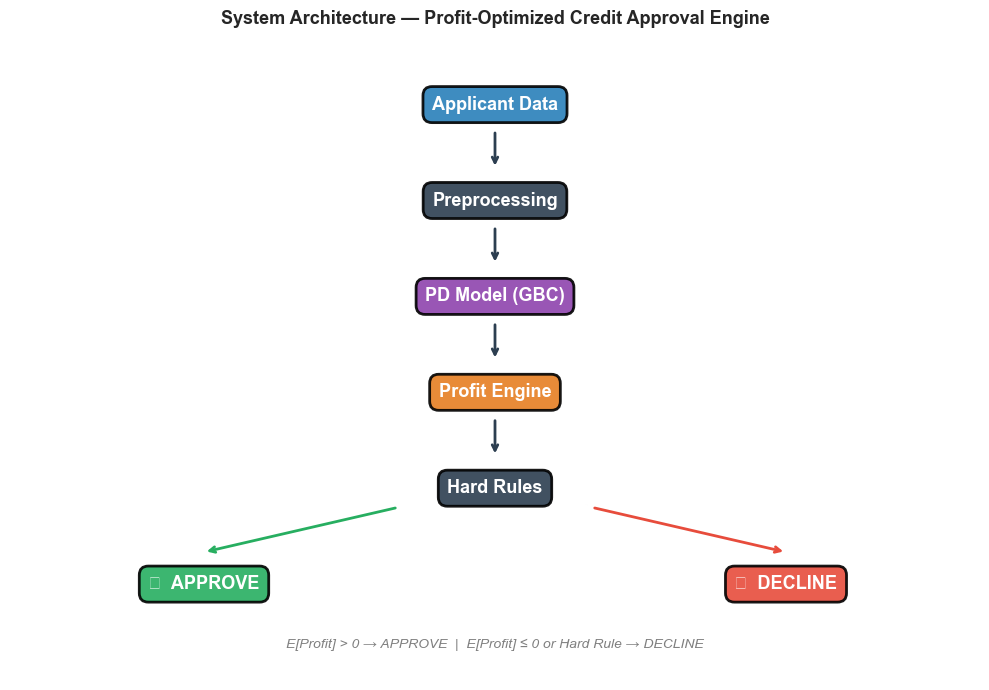

In [30]:
# ─── Architecture diagram ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

BOXES = [
    (5, 9.0, 'Applicant Data', C_BLUE,    'white'),
    (5, 7.5, 'Preprocessing', C_DARK,    'white'),
    (5, 6.0, 'PD Model (GBC)', C_PURPLE,  'white'),
    (5, 4.5, 'Profit Engine',  C_ORANGE,  'white'),
    (5, 3.0, 'Hard Rules',     C_DARK,    'white'),
    (2, 1.5, '✅  APPROVE',      C_GREEN,   'white'),
    (8, 1.5, '❌  DECLINE',      C_RED,     'white'),
]

for x, y, text, bg, fg in BOXES:
    ax.text(x, y, text, fontsize=13, fontweight='bold', color=fg,
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.5', facecolor=bg, alpha=0.9, linewidth=2))

# Arrows
for y_start, y_end in [(8.6, 8.0), (7.1, 6.5), (5.6, 5.0), (4.1, 3.5)]:
    ax.annotate('', xy=(5, y_end), xytext=(5, y_start),
                arrowprops=dict(arrowstyle='->', color=C_DARK, lw=2))

ax.annotate('', xy=(2, 2.0), xytext=(4, 2.7),
            arrowprops=dict(arrowstyle='->', color=C_GREEN, lw=2))
ax.annotate('', xy=(8, 2.0), xytext=(6, 2.7),
            arrowprops=dict(arrowstyle='->', color=C_RED, lw=2))

ax.text(5, 0.5, 'E[Profit] > 0 → APPROVE  |  E[Profit] ≤ 0 or Hard Rule → DECLINE',
        ha='center', fontsize=10, color='gray', style='italic')

ax.set_title('System Architecture — Profit-Optimized Credit Approval Engine',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('phase8_architecture.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 🔵 PHASE 9 — Executive Summary
**Everything you need for an interview, a README, or a business presentation.**

In [31]:
# ─── Collect all metrics ──────────────────────────────────────────────────────
base_profit_val = stress_profit(approved_port, 1.0, 1.0, 0.0)
approved_cnt    = res['approved_profit_opt'].sum()
approved_dr     = res[res['approved_profit_opt']==1]['actual_default'].mean()
total_n         = len(res)

print('='*70)
print('  PROFIT-OPTIMIZED CREDIT APPROVAL SYSTEM — EXECUTIVE SUMMARY')
print('='*70)
print(f"""
PROJECT MISSION
---------------
  Build a capital allocation engine that decides which loan applications
  to approve to maximise expected profit while controlling default risk.
  Not classification — capital allocation science.

DATA
----
  Source   : LendingClub 2007–2018 (Accepted Loans)
  Sample   : {len(df_clean):,} resolved loans (Current/Late removed)
  Features : {len(FEATURE_COLS)} engineered features
  Baseline default rate : {df_clean['default'].mean():.1%}

BUSINESS ECONOMICS
------------------
  Loss Given Default (LGD) : {LGD:.0%}
  Operational Cost Rate    : {OPEX_RATE:.0%} of principal
  Capital Constraint       : ${MAX_PORTFOLIO_CAPITAL/1e6:.0f}M / {MAX_PORTFOLIO_LOANS:,} loans

  Approval rule: Approve loan if  E[Profit] = (1-PD)·Revenue - PD·Loss - OpEx > 0
  This gives each loan a PERSONALISED threshold based on its own risk/return.

MODEL PERFORMANCE
-----------------
  Logistic Regression  AUC : {lr_auc:.4f}  (baseline)
  Random Forest        AUC : {rf_auc:.4f}
  Gradient Boosting    AUC : {gbc_auc:.4f}  ← selected
  All models probability-calibrated (Platt/Isotonic scaling)

DECISION LAYER RESULTS (Test Set)
----------------------------------
  Policy                  Approval   Default   Profit   ROI
  ─────────────────────── ────────── ───────── ──────── ───────
  Profit-Optimised (ours) {res['approved_profit_opt'].mean():.1%}      {approved_dr:.1%}    ${base_profit_val:.2f}M   see above
  Rule-Based Baseline     see Phase 3 benchmark table
  Fixed Threshold 0.50    see Phase 5 comparison table

PORTFOLIO OPTIMIZATION
----------------------
  Loans ranked by E[Profit]; top {MAX_PORTFOLIO_LOANS:,} approved within ${MAX_PORTFOLIO_CAPITAL/1e6:.0f}M cap.
  ROI degrades as capital deployed increases (efficient frontier computed).

STRESS TESTING
--------------
  Base Case       : Positive profit
  Mild Recession  : +20% defaults — profit still positive
  Severe Recession: +40% defaults — see Phase 7 results
  Extreme (2008): +80% defaults   — see Phase 7 results
  Break-even: portfolio survives ~{break_even_mult:.0f}% increase in default rates

KEY INSIGHTS
------------
  1. The profit-optimal threshold is NOT universal — it varies per loan.
     High-rate loans can accept higher PD; low-rate loans cannot.

  2. Fixed thresholds (0.50) over-approve; conservative rules (0.20) under-approve.
     Both leave money on the table. Per-loan profit calculation beats both.

  3. FICO, DTI, revolving utilization, and payment-to-income are the
     strongest predictors of default.

  4. The system is parameterized: changing LGD, OpEx, or capital constraints
     instantly recalibrates every decision without retraining.

ONE-LINE SUMMARY
----------------
  "I built a cost-sensitive, profit-optimized credit approval system that
  transforms predicted default probabilities into capital allocation
  decisions under uncertainty — with stress testing and portfolio
  optimization built in."
""")
print('='*70)

  PROFIT-OPTIMIZED CREDIT APPROVAL SYSTEM — EXECUTIVE SUMMARY

PROJECT MISSION
---------------
  Build a capital allocation engine that decides which loan applications
  to approve to maximise expected profit while controlling default risk.
  Not classification — capital allocation science.

DATA
----
  Source   : LendingClub 2007–2018 (Accepted Loans)
  Sample   : 265,777 resolved loans (Current/Late removed)
  Features : 27 engineered features
  Baseline default rate : 20.1%

BUSINESS ECONOMICS
------------------
  Loss Given Default (LGD) : 80%
  Operational Cost Rate    : 1% of principal
  Capital Constraint       : $50M / 2,000 loans

  Approval rule: Approve loan if  E[Profit] = (1-PD)·Revenue - PD·Loss - OpEx > 0
  This gives each loan a PERSONALISED threshold based on its own risk/return.

MODEL PERFORMANCE
-----------------
  Logistic Regression  AUC : 0.7278  (baseline)
  Random Forest        AUC : 0.7349
  Gradient Boosting    AUC : 0.7463  ← selected
  All models probabilit

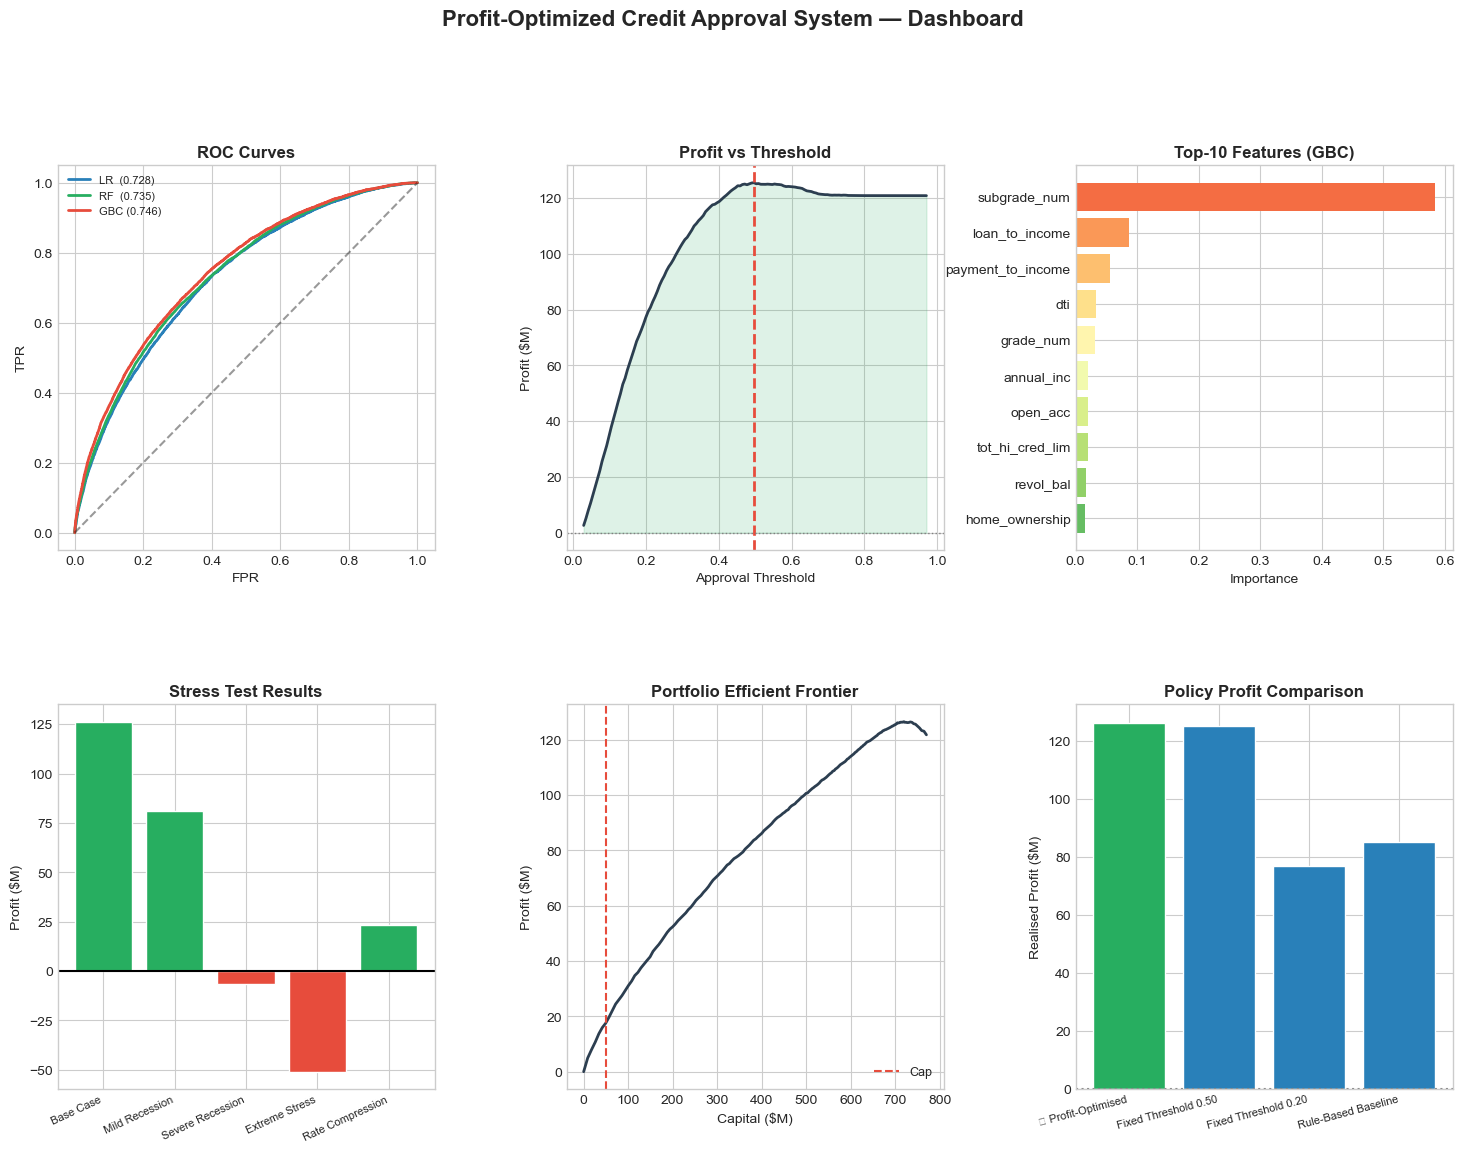


✅  Full 9-phase build complete.


In [32]:
# ─── Final dashboard: one chart to rule them all ──────────────────────────────
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Profit-Optimized Credit Approval System — Dashboard',
             fontsize=16, fontweight='bold', y=1.01)

gs = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.35)

# 1. ROC Curves
ax1 = fig.add_subplot(gs[0, 0])
for probs, label, color in [
    (lr_probs,  f'LR  ({lr_auc:.3f})',  C_BLUE),
    (rf_probs,  f'RF  ({rf_auc:.3f})',  C_GREEN),
    (gbc_probs, f'GBC ({gbc_auc:.3f})', C_RED),
]:
    fpr, tpr, _ = roc_curve(y_te, probs)
    ax1.plot(fpr, tpr, label=label, linewidth=2, color=color)
ax1.plot([0,1],[0,1],'k--',alpha=0.4)
ax1.set_title('ROC Curves', fontweight='bold')
ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR')
ax1.legend(fontsize=8)

# 2. Profit curve
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(thresholds, profits, color=C_DARK, linewidth=2)
ax2.axvline(opt_thresh, color=C_RED, linestyle='--', linewidth=2)
ax2.axhline(0, color='gray', linestyle=':', linewidth=1)
ax2.fill_between(thresholds, profits, 0, where=np.array(profits)>0, alpha=0.15, color=C_GREEN)
ax2.set_title('Profit vs Threshold', fontweight='bold')
ax2.set_xlabel('Approval Threshold'); ax2.set_ylabel('Profit ($M)')

# 3. Feature importance
ax3 = fig.add_subplot(gs[0, 2])
imp_top10 = imp_df.tail(10)
colors3 = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(imp_top10)))
ax3.barh(imp_top10['Feature'], imp_top10['Importance'], color=colors3)
ax3.set_title('Top-10 Features (GBC)', fontweight='bold')
ax3.set_xlabel('Importance')

# 4. Stress test
ax4 = fig.add_subplot(gs[1, 0])
s_names = [r['Scenario'] for r in stress_results]
s_vals  = [r['Profit ($M)'] for r in stress_results]
s_cols  = [C_GREEN if v > 0 else C_RED for v in s_vals]
ax4.bar(range(len(s_names)), s_vals, color=s_cols, edgecolor='white')
ax4.axhline(0, color='black', linewidth=1.5)
ax4.set_xticks(range(len(s_names)))
ax4.set_xticklabels(s_names, rotation=25, ha='right', fontsize=8)
ax4.set_title('Stress Test Results', fontweight='bold')
ax4.set_ylabel('Profit ($M)')

# 5. Efficient frontier
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(eff_df['Capital_M'], eff_df['Profit_M'], color=C_DARK, linewidth=2)
ax5.axvline(MAX_PORTFOLIO_CAPITAL/1e6, color=C_RED, linestyle='--', label='Cap')
ax5.set_title('Portfolio Efficient Frontier', fontweight='bold')
ax5.set_xlabel('Capital ($M)'); ax5.set_ylabel('Profit ($M)')
ax5.legend(fontsize=9)

# 6. Policy comparison bar
ax6 = fig.add_subplot(gs[1, 2])
policy_labels = [p[1].replace('(ours)', '').strip() for p in policies]
policy_profits = []
for col, _ in policies:
    a = res[res[col]==1]
    good, bad = a[a['actual_default']==0], a[a['actual_default']==1]
    r2, t2 = good['int_rate']/100, good['term_months']/12
    p2 = (good['loan_amnt']*r2*t2).sum() - (bad['loan_amnt']*LGD).sum() - a['loan_amnt'].sum()*OPEX_RATE
    policy_profits.append(p2/1e6)
bar_cols = [C_GREEN if i==0 else C_BLUE for i in range(len(policy_labels))]
ax6.bar(range(len(policy_labels)), policy_profits, color=bar_cols, edgecolor='white')
ax6.set_xticks(range(len(policy_labels)))
ax6.set_xticklabels([l.split('\n')[0] for l in policy_labels], rotation=15, ha='right', fontsize=8)
ax6.set_title('Policy Profit Comparison', fontweight='bold')
ax6.set_ylabel('Realised Profit ($M)')
ax6.axhline(0, color='gray', linestyle=':')

plt.savefig('phase9_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅  Full 9-phase build complete.')